In [8]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("C:/Users/gupta\Documents/GitHub/Last-Mile-Delivery-Delay-Root-Cause-Analysis/data/processed/final_deliveries_clean.csv")

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\gupta\AppData\Local\Temp\ipykernel_17492\1140245213.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  df=pd.read_csv("C:/Users/gupta\Documents/GitHub/Last-Mile-Delivery-Delay-Root-Cause-Analysis/data/processed/final_deliveries_clean.csv")


In [4]:
courier_avg= df.groupby('Delivery_person_ID')['Time_taken(min)'].mean()
z_scores=(courier_avg-courier_avg.mean())/ courier_avg.std()
print(z_scores)

Delivery_person_ID
AGRRES010DEL01    -0.953257
AGRRES010DEL02     1.265373
AGRRES010DEL03     0.654158
AGRRES01DEL01      0.250650
AGRRES01DEL02     -0.990112
                     ...   
VADRES19DEL02      0.292918
VADRES19DEL03     -0.053473
VADRES20DEL01      0.345389
VADRES20DEL02     -0.354743
VADRES20DEL03     -0.151427
Name: Time_taken(min), Length: 1320, dtype: float64


In [6]:
outliers= z_scores[z_scores>3].sort_values(ascending=False)
good= z_scores[z_scores<-1].sort_values()
print("=" * 45)
print("        Z-SCORE COURIER ANALYSIS")
print("=" * 45)
print(f"\n📊 Fleet Stats:")
print(f"   Total couriers    : {len(courier_avg)}")
print(f"   Fleet avg time    : {courier_avg.mean():.1f} min")
print(f"   Std deviation     : {courier_avg.std():.1f} min")

print(f"\n⚠ Outlier Couriers (Z > 3) — Need Retraining:")
print(f"   Count : {len(outliers)}")
print(outliers.round(2).to_string())

print(f"\n⭐ Top Performers (Z < -1) — Best Couriers:")
print(f"   Count : {len(good)}")
print(good.head(5).round(2).to_string())

print("\n" + "=" * 45)


        Z-SCORE COURIER ANALYSIS

📊 Fleet Stats:
   Total couriers    : 1320
   Fleet avg time    : 26.3 min
   Std deviation     : 1.9 min

⚠ Outlier Couriers (Z > 3) — Need Retraining:
   Count : 7
Delivery_person_ID
ALHRES12DEL01      4.46
KOLRES19DEL02      3.86
AGRRES17DEL01      3.78
KNPRES14DEL01      3.36
GOARES08DEL03      3.12
ALHRES010DEL01     3.03
KOLRES03DEL03      3.01

⭐ Top Performers (Z < -1) — Best Couriers:
   Count : 172
Delivery_person_ID
KOLRES06DEL03    -3.56
DEHRES20DEL03    -3.48
DEHRES17DEL01    -3.40
KOLRES01DEL03    -3.37
KNPRES01DEL01    -3.28



### Visual of Z-Score 

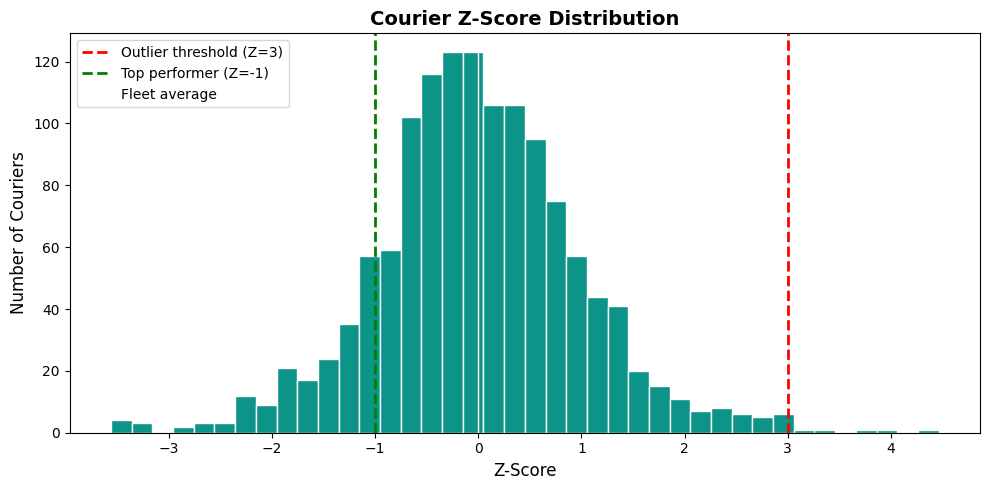

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(z_scores, bins=40, color='#0D9488', edgecolor='white')
plt.axvline(x=3,  color='red',   linestyle='--', linewidth=2, label='Outlier threshold (Z=3)')
plt.axvline(x=-1, color='green', linestyle='--', linewidth=2, label='Top performer (Z=-1)')
plt.axvline(x=0,  color='white', linestyle='-',  linewidth=1, label='Fleet average')
plt.title('Courier Z-Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Z-Score', fontsize=12)
plt.ylabel('Number of Couriers', fontsize=12)
plt.legend()
plt.tight_layout()
# plt.savefig('outputs/B2_zscore_couriers.png', dpi=150)
plt.show()

### Key Finding:
Fleet is well-distributed — this means delivery delays are NOT primarily a behavioural problem. The root cause likely lies more in Environmental or Structural buckets — which matches your T-Test finding (weather adds 7 min).

# ── B3: Correlation Matrix ────────────────────────────────


In [11]:
df_encoded= pd.get_dummies(df[['Time_taken(min)',
                               'Distance from Hub',
                                'Minutes_Per_KM',
                                'Delivery_person_Age',
                                'Delivery_person_Ratings',
                                'Vehicle_condition',
                                'multiple_deliveries',
                                'Weatherconditions',
                                'Road_traffic_density',
                                'City',
                                'Festival',
                                'Experience']], drop_first=True)

In [12]:
corr = df_encoded.corr()[['Time_taken(min)']]\
                 .drop('Time_taken(min)')\
                 .sort_values('Time_taken(min)', ascending=False)

print("=" * 45)
print("   CORRELATION WITH Time_taken(min)")
print("=" * 45)
print(corr.round(3).to_string())
print("=" * 45)

   CORRELATION WITH Time_taken(min)
                                         Time_taken(min)
multiple_deliveries                                0.378
Road_traffic_density_Jam                           0.349
Delivery_person_Age                                0.293
Festival_Yes                                       0.290
Experience_Senior                                  0.195
City_Semi-Urban                                    0.150
Weatherconditions_conditions Fog                   0.125
Minutes_Per_KM                                     0.069
Road_traffic_density_Medium                        0.024
Weatherconditions_conditions NaN                   0.003
Road_traffic_density_NaN                           0.003
Distance from Hub                                 -0.003
Weatherconditions_conditions Windy                -0.008
Weatherconditions_conditions Sandstorms           -0.020
Weatherconditions_conditions Stormy               -0.020
City_NaN                                          -0

C:\Users\gupta\AppData\Local\Temp\ipykernel_17492\2986214908.py:19: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gupta\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


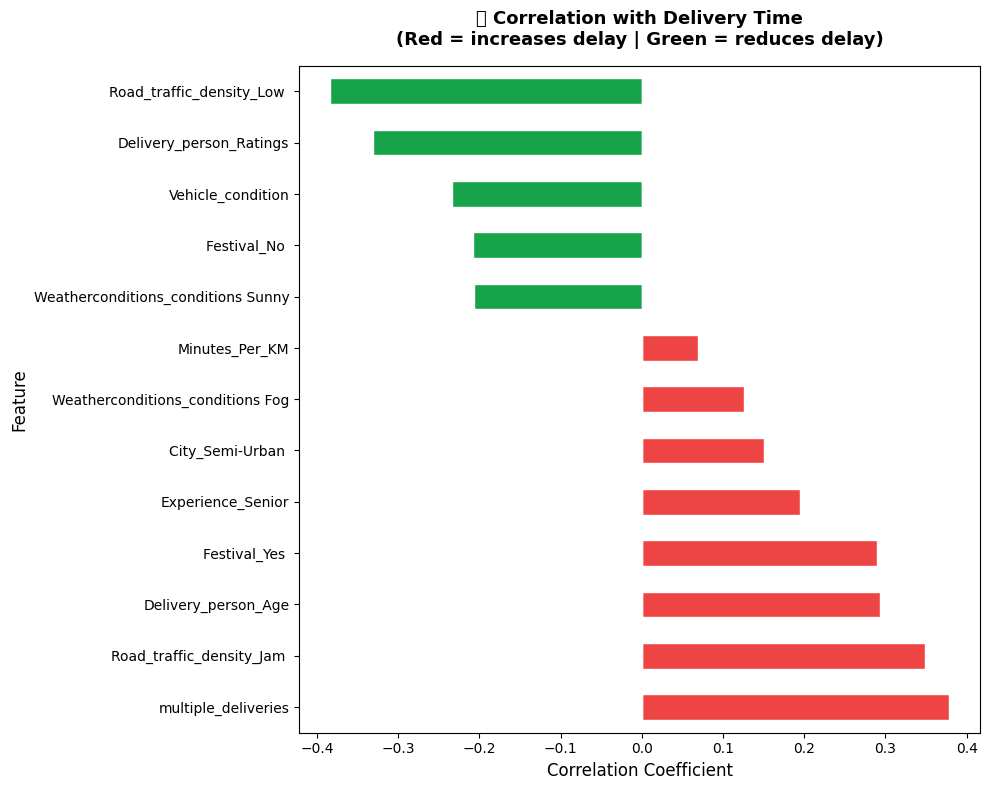

In [13]:
plt.figure(figsize=(10, 8))

top_corr = pd.concat([corr.head(8), corr.tail(5)])

colors = ['#EF4444' if x > 0 else '#16A34A' 
          for x in top_corr['Time_taken(min)']]

top_corr['Time_taken(min)'].plot(
    kind='barh',
    color=colors,
    edgecolor='white'
)

plt.axvline(x=0, color='white', linewidth=1)
plt.title('🔗 Correlation with Delivery Time\n(Red = increases delay | Green = reduces delay)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
# plt.savefig('outputs/B3_correlation.png', dpi=150)
plt.show()

### Insight of Correction Chart :
"Multiple deliveries per trip is the single strongest delay driver (r=0.38), beating even Jam traffic (r=0.35). This means the dispatch system is overloading couriers. The fix is NOT more vehicles — it is smarter order batching. Additionally, Festival_Yes (r=0.29) confirms India-specific seasonal planning is missing from operations."